# HV-Doc-Data — Download from Kaggle + Train U-Net

Run **top to bottom** on Google Colab (`Runtime → Change runtime type → T4 GPU`).

**What this notebook does:**
1. Downloads `yashvardhangera/hv-doc-data` from Kaggle via an interactive token prompt
2. Copies the dataset into `/content/` so it's visible in the file browser
3. Picks one of the three training-round CSVs and trains a U-Net
4. Saves a checkpoint, then lets you load **any** checkpoint to generate `pred.csv`

**Before you start:** go to [kaggle.com/settings](https://www.kaggle.com/settings) → **API** → **Create New Token** — you'll be asked to paste your username and key in the auth cell below.

## 1 — Install dependencies

In [1]:
!pip install -q kagglehub albumentations tqdm
print("done installing")

done installing


## 2 — Kaggle authentication

Run this cell and follow the prompt to paste your Kaggle username and API key.

In [2]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


## 3 — Download and copy dataset to `/content/`

`kagglehub` caches to `/root/.cache/...` — not visible in the Colab file browser. This cell downloads the dataset, finds the actual data directory (the Kaggle package nests it under `student/student/`), then copies images and labels into `/content/dataset/` where you can browse them.

In [3]:
import kagglehub, os, shutil, glob

# Step 1 — download to the kagglehub cache (~/.cache/kagglehub/...)
_cache_path = kagglehub.dataset_download("yashvardhangera/hv-doc-data")
print("Kaggle cache path:", _cache_path)

# Step 2 — find the subdirectory that actually contains images/ and labels/
# (the Kaggle package nests the data under student/student/)
def _find_data_root(base):
    for root, dirs, _ in os.walk(base):
        if "images" in dirs and "labels" in dirs:
            return root
    raise RuntimeError(f"Could not find a folder with both images/ and labels/ under {base}")

_data_root = _find_data_root(_cache_path)
print("Data root found at:", _data_root)

# Step 3 — copy into /content/dataset/ so it's visible in the file browser
CONTENT_DATA = "/content/dataset"

if os.path.exists(CONTENT_DATA):
    print(f"{CONTENT_DATA} already exists, skipping copy")
else:
    print("Copying to /content/dataset/ ...")
    shutil.copytree(_data_root, CONTENT_DATA)
    print("Done.")

# Step 4 — copy seg_common.py to /content/ so it's importable
_sc_src = os.path.join(_cache_path, "seg_common.py")
if os.path.exists(_sc_src) and not os.path.exists("/content/seg_common.py"):
    shutil.copy(_sc_src, "/content/seg_common.py")
    print("Copied seg_common.py → /content/seg_common.py")

# Verify
print("\n/content/dataset/ layout:")
for root, dirs, files in os.walk(CONTENT_DATA):
    depth = root[len(CONTENT_DATA):].count(os.sep)
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root) or root}/")
    for f in sorted(files)[:4]:
        print(f"{indent}  {f}")
    if len(files) > 4:
        print(f"{indent}  ... ({len(files)} files total)")

Using Colab cache for faster access to the 'hv-doc-data' dataset.
Kaggle cache path: /kaggle/input/hv-doc-data
Data root found at: /kaggle/input/hv-doc-data/student/student
Copying to /content/dataset/ ...
Done.
Copied seg_common.py → /content/seg_common.py

/content/dataset/ layout:
dataset/
  labels/
    train_round_1.csv
    train_round_2.csv
    train_round_3.csv
  images/
    test/
      test_00000.jpg
      test_00001.jpg
      test_00002.jpg
      test_00003.jpg
      ... (1000 files total)
    train/
      train_00000.jpg
      train_00001.jpg
      train_00002.jpg
      train_00003.jpg
      ... (5000 files total)


## 4 — Index all images and CSVs

In [4]:
ALL_CSVS = sorted(glob.glob(os.path.join(CONTENT_DATA, "**", "*.csv"), recursive=True))
ALL_IMAGES = sorted(
    glob.glob(os.path.join(CONTENT_DATA, "**", "*.jpg"),  recursive=True) +
    glob.glob(os.path.join(CONTENT_DATA, "**", "*.jpeg"), recursive=True) +
    glob.glob(os.path.join(CONTENT_DATA, "**", "*.png"),  recursive=True)
)

print(f"CSVs  : {len(ALL_CSVS)}")
for p in ALL_CSVS:
    print(" ", p)
print(f"Images: {len(ALL_IMAGES)}  (first few below)")
for p in ALL_IMAGES[:4]:
    print(" ", p)

assert ALL_CSVS,   "No CSV files found under /content/dataset/"
assert ALL_IMAGES, "No image files found under /content/dataset/"

# filename -> full /content/ path
image_lookup = {os.path.basename(p): p for p in ALL_IMAGES}

# test images (used later for pred.csv)
TEST_IMAGE_PATHS = sorted(p for p in ALL_IMAGES if os.path.basename(p).startswith("test_"))
print(f"\nTrain images: {sum(1 for p in ALL_IMAGES if os.path.basename(p).startswith('train_'))}")
print(f"Test  images: {len(TEST_IMAGE_PATHS)}")

CSVs  : 3
  /content/dataset/labels/train_round_1.csv
  /content/dataset/labels/train_round_2.csv
  /content/dataset/labels/train_round_3.csv
Images: 6000  (first few below)
  /content/dataset/images/test/test_00000.jpg
  /content/dataset/images/test/test_00001.jpg
  /content/dataset/images/test/test_00002.jpg
  /content/dataset/images/test/test_00003.jpg

Train images: 5000
Test  images: 1000


#Forensics

STEP 1 — Label forensics + exact local eval harness.

Paste each `# %% CELL` block into its own Colab cell.
Nothing here trains anything; it only characterises the three annotation rounds
and gives you a scorer that mirrors seg_common.seg_prf_report.

Assumes /content/dataset exists (from your Section 3 cell).

In [6]:
# %% CELL A — setup + raw peek at the CSVs
import os, json, itertools
from collections import Counter

import cv2
import numpy as np
import pandas as pd

CONTENT_DATA = "/content/dataset"
LABEL_DIR = os.path.join(CONTENT_DATA, "labels")
GRID = 256                      # the grid the scorer rasterises on
ROUNDS = (1, 2, 3)

# raw peek: we need to see what `corners` actually holds
_peek = pd.read_csv(os.path.join(LABEL_DIR, "train_round_1.csv"), nrows=3)
print("columns:", list(_peek.columns))
for c in _peek.columns:
    print(f"\n--- {c} ---")
    for v in _peek[c].tolist():
        s = str(v)
        print(s[:300] + ("..." if len(s) > 300 else ""))


columns: ['image', 'polygon', 'corners']

--- image ---
train_00000.jpg
train_00001.jpg
train_00002.jpg

--- polygon ---
[[[0.38114, 0.05503], [0.39921, 0.05843], [0.42112, 0.06359], [0.44232, 0.06871], [0.46298, 0.07342], [0.48513, 0.07761], [0.50469, 0.08147], [0.52716, 0.08561], [0.54696, 0.08825], [0.56774, 0.09074], [0.58851, 0.09366], [0.6101, 0.09675], [0.63064, 0.10195], [0.64804, 0.10505], [0.66678, 0.10783],...
[[[0.20228, 0.34739], [0.21877, 0.33992], [0.2384, 0.33129], [0.25526, 0.32238], [0.2726, 0.31283], [0.29265, 0.30304], [0.3122, 0.29373], [0.33575, 0.28343], [0.35836, 0.27352], [0.38286, 0.26385], [0.40952, 0.25477], [0.43765, 0.24653], [0.46629, 0.23965], [0.49573, 0.23355], [0.52252, 0.22859], [...
[[[0.06058, 0.24662], [0.08594, 0.24049], [0.11822, 0.23494], [0.14978, 0.2295], [0.18049, 0.22418], [0.21275, 0.21859], [0.24179, 0.21362], [0.27501, 0.20832], [0.30542, 0.20273], [0.33666, 0.19778], [0.36777, 0.19289], [0.39883, 0.18799], [0.42991, 0.18354], [0.45616, 

In [9]:
# %% CELL B — load all three rounds into a common structure -------------------
def _parse(cell):
    if isinstance(cell, str):
        try:
            return json.loads(cell)
        except json.JSONDecodeError:
            return None
    return cell


def load_round(r):
    df = pd.read_csv(os.path.join(LABEL_DIR, f"train_round_{r}.csv"))
    df = df.drop_duplicates(subset="image").reset_index(drop=True)
    out = {}
    for row in df.itertuples(index=False):
        out[row.image] = {
            "polygons": _parse(row.polygon) or [],
            "corners": _parse(getattr(row, "corners", None)),
        }
    return out


R = {r: load_round(r) for r in ROUNDS}
IMAGES = sorted(set.intersection(*[set(R[r]) for r in ROUNDS]))
print(f"images present in all three rounds: {len(IMAGES)}")
for r in ROUNDS:
    print(f"  round {r}: {len(R[r])} rows")

images present in all three rounds: 5000
  round 1: 5000 rows
  round 2: 5000 rows
  round 3: 5000 rows


In [11]:
# %% CELL C — rasterisation + IoU helpers (mirrors seg_common) ----------------
def polys_to_instances(polys, size=GRID):
    """One boolean mask per polygon — identical to seg_common.polys_to_instances."""
    out = []
    for p in polys:
        if p and len(p) >= 3:
            m = np.zeros((size, size), np.uint8)
            pts = (np.array(p, np.float32) * size).astype(np.int32)
            cv2.fillPoly(m, [pts], 1)
            out.append(m.astype(bool))
    return out


def union_mask(polys, size=GRID):
    m = np.zeros((size, size), bool)
    for inst in polys_to_instances(polys, size):
        m |= inst
    return m


def iou(a, b):
    u = np.logical_or(a, b).sum()
    return 0.0 if u == 0 else float(np.logical_and(a, b).sum()) / float(u)


def match_counts(preds, gts, thr):
    """Greedy one-to-one matching — identical to seg_common.match_counts."""
    matched, tp = set(), 0
    for gt in gts:
        best_iou, best_j = -1.0, -1
        for j, pred in enumerate(preds):
            if j in matched:
                continue
            v = iou(pred, gt)
            if v >= thr and v > best_iou:
                best_iou, best_j = v, j
        if best_j >= 0:
            tp += 1
            matched.add(best_j)
    return tp, len(preds) - len(matched), len(gts) - tp


def score(pred_polys_by_img, gt_polys_by_img, thrs=(0.9, 0.75, 0.5), size=GRID):
    """Instance P/R/F1 at each threshold + union pixel Dice. Mirrors the server."""
    keys = list(gt_polys_by_img)
    preds = [polys_to_instances(pred_polys_by_img.get(k, []), size) for k in keys]
    gts = [polys_to_instances(gt_polys_by_img[k], size) for k in keys]

    rep = {"images": len(keys), "iou": {}}
    for thr in thrs:
        TP = FP = FN = 0
        for p, g in zip(preds, gts):
            a, b, c = match_counts(p, g, thr)
            TP += a; FP += b; FN += c
        P = TP / (TP + FP) if TP + FP else 0.0
        Rc = TP / (TP + FN) if TP + FN else 0.0
        F1 = 2 * P * Rc / (P + Rc) if P + Rc else 0.0
        rep["iou"][thr] = {"P": P, "R": Rc, "F1": F1, "TP": TP, "FP": FP, "FN": FN}

    dices = []
    for p, g in zip(preds, gts):
        if not p and not g:
            dices.append(1.0); continue
        pu = np.zeros((size, size), bool)
        for m in p: pu |= m
        gu = np.zeros((size, size), bool)
        for m in g: gu |= m
        dices.append((2 * np.logical_and(pu, gu).sum() + 1e-6) / (pu.sum() + gu.sum() + 1e-6))
    rep["dice_mean"] = float(np.mean(dices))
    return rep


def print_report(name, rep, primary=0.9):
    print(f"\n=== {name}  (n={rep['images']}) ===")
    for thr, m in rep["iou"].items():
        star = "  <- PRIMARY" if abs(thr - primary) < 1e-9 else ""
        print(f"  IoU>={thr:.2f}  P {m['P']:.4f}  R {m['R']:.4f}  F1 {m['F1']:.4f}"
              f"   (TP {m['TP']} FP {m['FP']} FN {m['FN']}){star}")
    print(f"  pixel Dice (union): {rep['dice_mean']:.4f}")

In [13]:
# %% CELL D — per-image geometry for every round ------------------------------
def geom(polys, size=GRID):
    """Union-mask area fraction, centroid, instance count, vertex counts."""
    m = union_mask(polys, size)
    a = m.sum()
    if a == 0:
        return {"n": len(polys), "area": 0.0, "cx": np.nan, "cy": np.nan,
                "verts": [len(p) for p in polys]}
    ys, xs = np.nonzero(m)
    return {"n": len(polys), "area": a / float(size * size),
            "cx": xs.mean() / size, "cy": ys.mean() / size,
            "verts": [len(p) for p in polys]}


masks = {r: {} for r in ROUNDS}
G = {r: {} for r in ROUNDS}
for img in IMAGES:
    for r in ROUNDS:
        polys = R[r][img]["polygons"]
        masks[r][img] = union_mask(polys)
        G[r][img] = geom(polys)

rows = []
for img in IMAGES:
    row = {"image": img}
    for r in ROUNDS:
        g = G[r][img]
        row[f"n{r}"] = g["n"]
        row[f"area{r}"] = g["area"]
        row[f"cx{r}"] = g["cx"]
        row[f"cy{r}"] = g["cy"]
        row[f"v{r}"] = tuple(g["verts"])
    for a, b in itertools.combinations(ROUNDS, 2):
        row[f"iou{a}{b}"] = iou(masks[a][img], masks[b][img])
    rows.append(row)

D = pd.DataFrame(rows)
print(D.shape)
D.head()


(5000, 19)


,image,n1,area1,cx1,cy1,v1,n2,area2,cx2,cy2,v2,n3,area3,cx3,cy3,v3,iou12,iou13,iou23
0,train_00000.jpg,1,0.205154,0.559941,0.284635,"(100,)",1,0.205154,0.559941,0.284635,"(100,)",1,0.205154,0.559941,0.284635,"(100,)",1.000000,1.000000,1.000000
1,train_00001.jpg,1,0.358398,0.553483,0.561061,"(100,)",1,0.358398,0.553483,0.561061,"(100,)",1,0.347946,0.556612,0.553691,"(70,)",1.000000,0.970836,0.970836
2,train_00002.jpg,1,0.432358,0.511226,0.452114,"(100,)",1,0.432358,0.511226,0.452114,"(100,)",1,0.432358,0.511226,0.452114,"(100,)",1.000000,1.000000,1.000000
3,train_00003.jpg,1,0.299103,0.514897,0.496060,"(78,)",1,0.326569,0.496820,0.476451,"(100,)",1,0.326569,0.496820,0.476451,"(100,)",0.915896,0.915896,1.000000
4,train_00004.jpg,1,0.287384,0.320672,0.557368,"(100,)",1,0.287384,0.320672,0.557368,"(100,)",1,0.287384,0.320672,0.557368,"(100,)",1.000000,1.000000,1.000000


In [15]:
# %% CELL E — headline agreement statistics  -----------------------------------
print("=== pairwise union-mask IoU between annotators ===")
for a, b in itertools.combinations(ROUNDS, 2):
    c = D[f"iou{a}{b}"]
    print(f"  round{a} vs round{b}:  mean {c.mean():.4f}  median {c.median():.4f}  "
          f"| frac>=0.9 {(c >= 0.9).mean():.3f}  frac>=0.99 {(c >= 0.99).mean():.3f}  "
          f"| frac<0.5 {(c < 0.5).mean():.3f}")

print("\n=== each round's mean IoU against the other two ===")
mean_to_others = {}
for r in ROUNDS:
    cols = [f"iou{min(r,o)}{max(r,o)}" for o in ROUNDS if o != r]
    mean_to_others[r] = D[cols].mean(axis=1)
    print(f"  round {r}: {mean_to_others[r].mean():.4f}")
MO = pd.DataFrame(mean_to_others)

print("\n=== IoU histogram (is disagreement uniform, or a corrupted subset?) ===")
bins = [0, .2, .4, .6, .7, .8, .85, .9, .95, .99, 1.001]
for a, b in itertools.combinations(ROUNDS, 2):
    h = np.histogram(D[f"iou{a}{b}"], bins=bins)[0]
    print(f"  {a}v{b}: " + "  ".join(f"[{bins[i]:.2f}-{bins[i+1]:.2f}]={h[i]}"
                                     for i in range(len(h))))

print("\n=== instance-count agreement ===")
print("  count triples (n1,n2,n3) ->",
      Counter(zip(D.n1, D.n2, D.n3)).most_common(10))
for r in ROUNDS:
    print(f"  round {r} instance-count distribution:", Counter(D[f'n{r}']).most_common())

print("\n=== vertex counts per polygon ===")
for r in ROUNDS:
    vc = Counter(v for t in D[f"v{r}"] for v in t)
    print(f"  round {r}:", vc.most_common(8))

print("\n=== systematic bias: area fraction & centroid ===")
for r in ROUNDS:
    print(f"  round {r}: mean area {D[f'area{r}'].mean():.4f}  "
          f"cx {D[f'cx{r}'].mean():.4f}  cy {D[f'cy{r}'].mean():.4f}")
med_area = D[[f"area{r}" for r in ROUNDS]].median(axis=1)
for r in ROUNDS:
    ratio = D[f"area{r}"] / med_area.replace(0, np.nan)
    print(f"  round {r}: area / median-area  mean {ratio.mean():.4f}  "
          f"median {ratio.median():.4f}  std {ratio.std():.4f}")

=== pairwise union-mask IoU between annotators ===
  round1 vs round2:  mean 0.9960  median 1.0000  | frac>=0.9 0.991  frac>=0.99 0.931  | frac<0.5 0.000
  round1 vs round3:  mean 0.9960  median 1.0000  | frac>=0.9 0.991  frac>=0.99 0.932  | frac<0.5 0.000
  round2 vs round3:  mean 0.9961  median 1.0000  | frac>=0.9 0.992  frac>=0.99 0.932  | frac<0.5 0.000

=== each round's mean IoU against the other two ===
  round 1: 0.9960
  round 2: 0.9960
  round 3: 0.9961

=== IoU histogram (is disagreement uniform, or a corrupted subset?) ===
  1v2: [0.00-0.20]=0  [0.20-0.40]=0  [0.40-0.60]=0  [0.60-0.70]=0  [0.70-0.80]=7  [0.80-0.85]=11  [0.85-0.90]=25  [0.90-0.95]=108  [0.95-0.99]=192  [0.99-1.00]=4657
  1v3: [0.00-0.20]=0  [0.20-0.40]=0  [0.40-0.60]=0  [0.60-0.70]=0  [0.70-0.80]=4  [0.80-0.85]=13  [0.85-0.90]=26  [0.90-0.95]=112  [0.95-0.99]=183  [0.99-1.00]=4662
  2v3: [0.00-0.20]=0  [0.20-0.40]=0  [0.40-0.60]=0  [0.60-0.70]=0  [0.70-0.80]=4  [0.80-0.85]=8  [0.85-0.90]=26  [0.90-0.95]=114  

In [16]:
# %% CELL F — who is the outlier, and how often? ------------------------------
# For each image, the "odd one out" is the round with the lowest mean IoU to the
# other two. If corruption is a random subset, this should be ~uniform across
# rounds but concentrated on the corrupted images.
worst = MO.idxmin(axis=1)
gap = MO.max(axis=1) - MO.min(axis=1)

print("=== odd-one-out counts (all images) ===")
print(Counter(worst).most_common())

for g in (0.02, 0.05, 0.10, 0.25):
    sel = gap > g
    print(f"\n=== images where the gap > {g}: {sel.sum()} ({sel.mean():.1%}) ===")
    print("   ", Counter(worst[sel]).most_common())

print("\n=== per-round: fraction of images where that round is the outlier "
      "with a >0.05 gap ===")
for r in ROUNDS:
    frac = ((worst == r) & (gap > 0.05)).mean()
    print(f"  round {r}: {frac:.3f}")

D["worst_round"] = worst.values
D["gap"] = gap.values

=== odd-one-out counts (all images) ===
[(1, 4525), (3, 239), (2, 236)]

=== images where the gap > 0.02: 297 (5.9%) ===
    [(3, 106), (2, 98), (1, 93)]

=== images where the gap > 0.05: 62 (1.2%) ===
    [(1, 24), (2, 19), (3, 19)]

=== images where the gap > 0.1: 7 (0.1%) ===
    [(2, 4), (1, 3)]

=== images where the gap > 0.25: 0 (0.0%) ===
    []

=== per-round: fraction of images where that round is the outlier with a >0.05 gap ===
  round 1: 0.005
  round 2: 0.004
  round 3: 0.004


In [17]:
# %% CELL G — characterise the disagreements -----------------------------------
# For the images where an annotator is the outlier, what KIND of error is it?
def classify(img, r_bad):
    others = [o for o in ROUNDS if o != r_bad]
    gb, go = G[r_bad][img], [G[o][img] for o in others]
    n_o = int(np.median([g["n"] for g in go]))
    if gb["n"] != n_o:
        return "instance_count_mismatch"
    a_o = float(np.median([g["area"] for g in go]))
    if a_o <= 0:
        return "degenerate"
    ar = gb["area"] / a_o
    cx_o = float(np.nanmedian([g["cx"] for g in go]))
    cy_o = float(np.nanmedian([g["cy"] for g in go]))
    shift = np.hypot(gb["cx"] - cx_o, gb["cy"] - cy_o)
    if ar < 0.85:
        return "shrunken"
    if ar > 1.15:
        return "enlarged"
    if shift > 0.03:
        return "translated"
    return "vertex_jitter_or_rotation"


bad = D[D.gap > 0.05]
print(f"analysing {len(bad)} disputed images")
cls = Counter()
per_round = {r: Counter() for r in ROUNDS}
for row in bad.itertuples(index=False):
    c = classify(row.image, row.worst_round)
    cls[c] += 1
    per_round[row.worst_round][c] += 1
print("\n=== error type overall ===")
for k, v in cls.most_common():
    print(f"  {k}: {v}")
print("\n=== error type by round ===")
for r in ROUNDS:
    print(f"  round {r}: {per_round[r].most_common()}")

analysing 62 disputed images

=== error type overall ===
  translated: 27
  shrunken: 23
  vertex_jitter_or_rotation: 12

=== error type by round ===
  round 1: [('shrunken', 11), ('translated', 7), ('vertex_jitter_or_rotation', 6)]
  round 2: [('translated', 9), ('shrunken', 7), ('vertex_jitter_or_rotation', 3)]
  round 3: [('translated', 11), ('shrunken', 5), ('vertex_jitter_or_rotation', 3)]


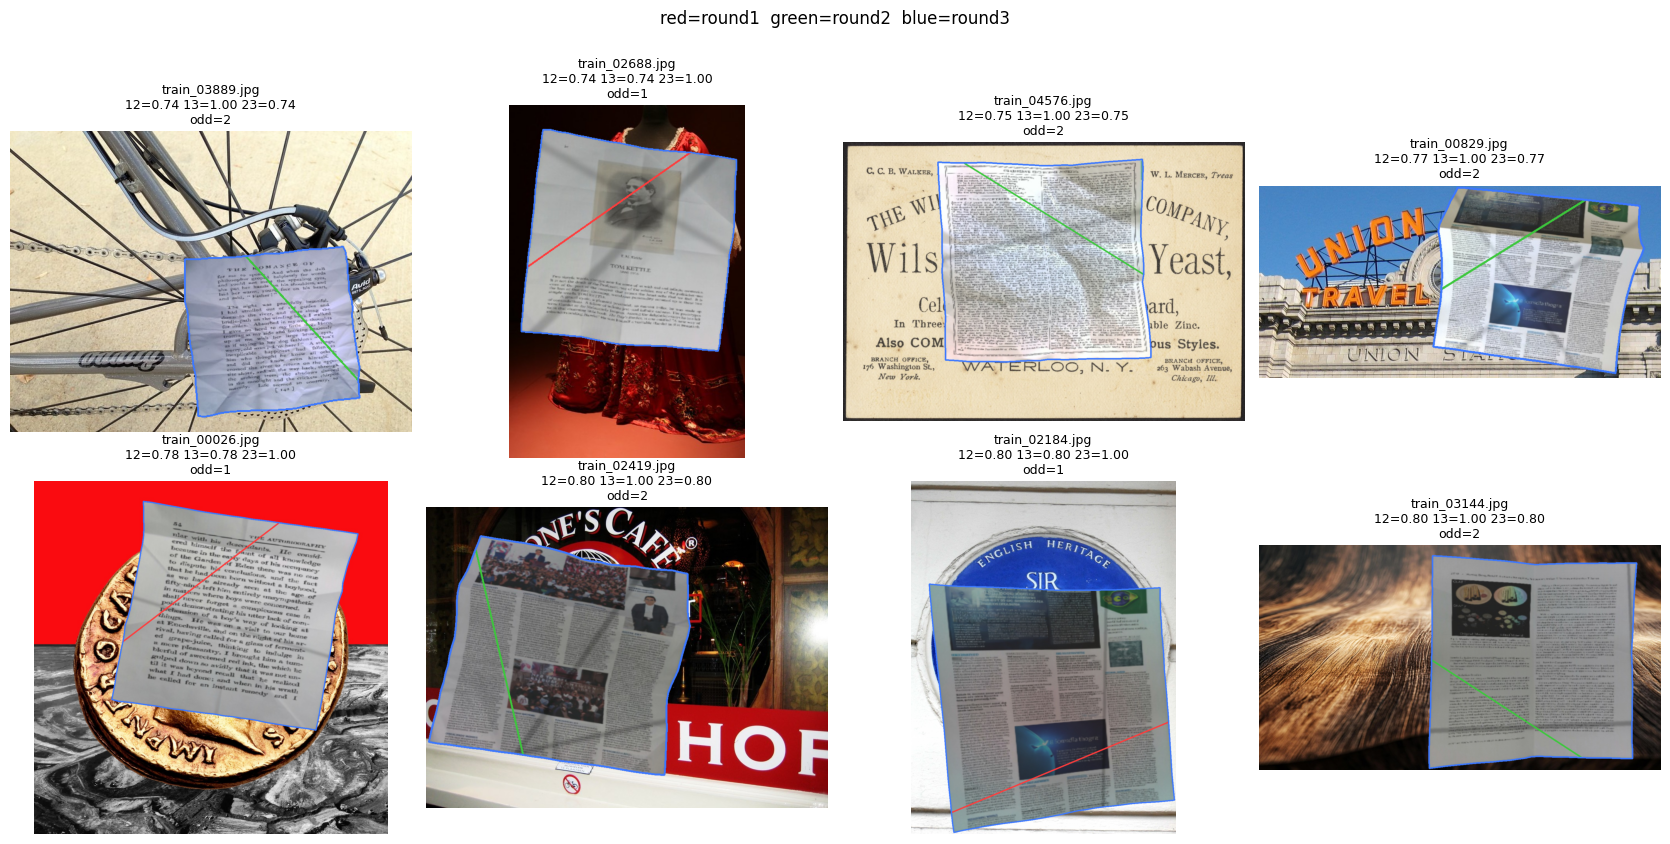

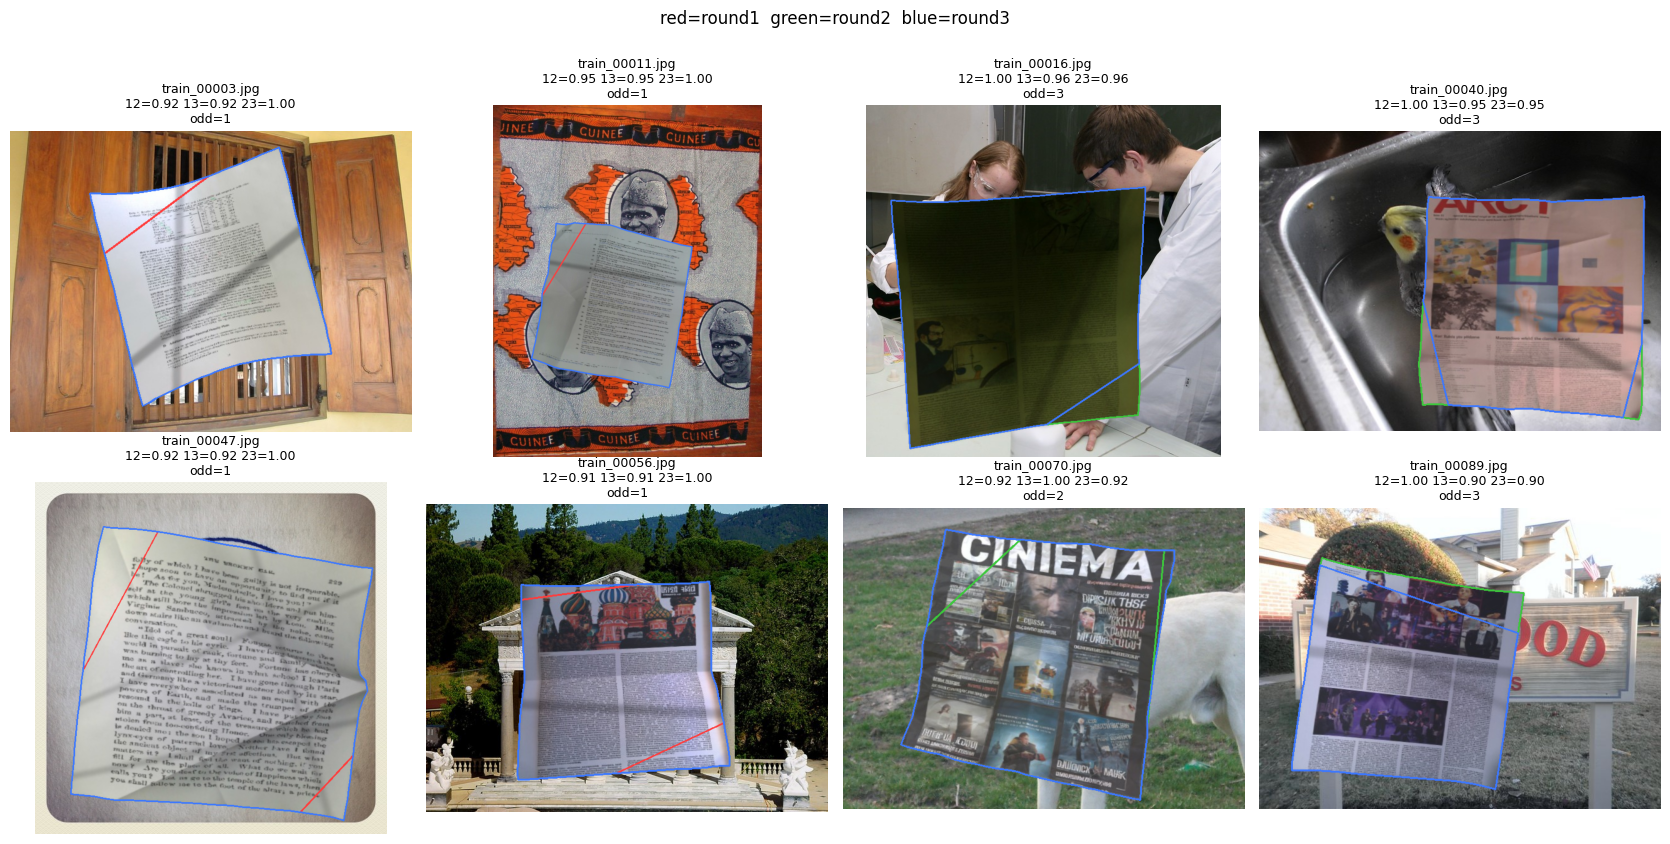

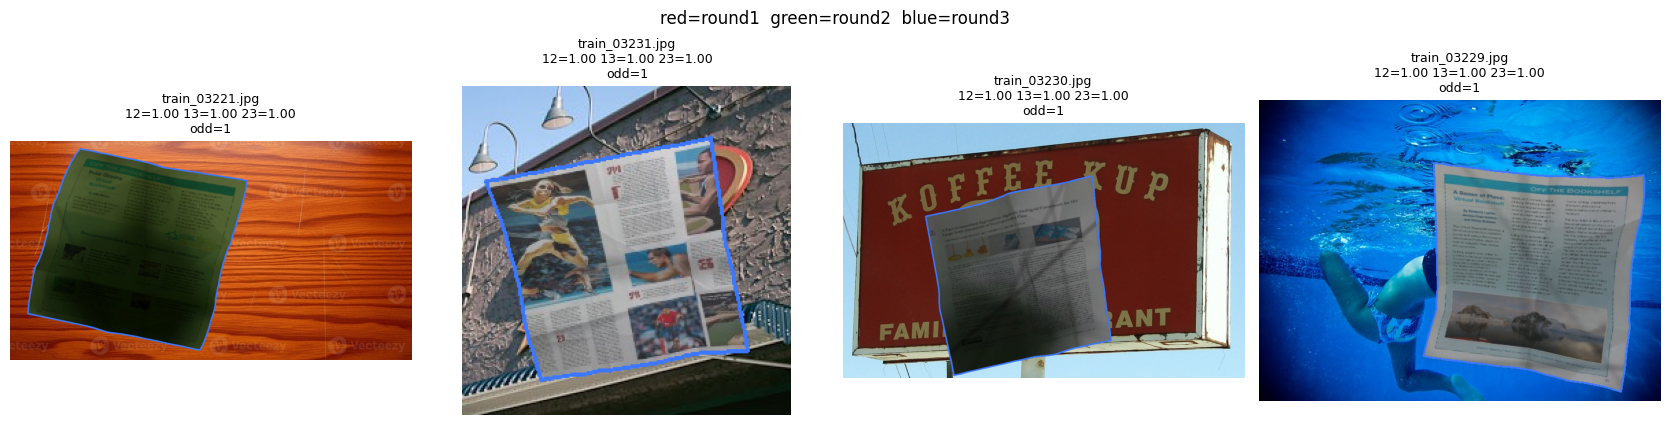

In [19]:
# %% CELL H — visual check on the worst disagreements --------------------------
import matplotlib.pyplot as plt

image_lookup = {}
for split in ("train", "test"):
    d = os.path.join(CONTENT_DATA, "images", split)
    for f in os.listdir(d):
        image_lookup[f] = os.path.join(d, f)

COLORS = {1: (255, 60, 60), 2: (60, 200, 60), 3: (60, 120, 255)}


def show(img_names, ncols=4):
    n = len(img_names)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.2 * nrows))
    for ax, name in zip(np.atleast_1d(axes).ravel(), img_names):
        im = cv2.cvtColor(cv2.imread(image_lookup[name]), cv2.COLOR_BGR2RGB)
        H, W = im.shape[:2]
        vis = im.copy()
        for r in ROUNDS:
            for p in R[r][name]["polygons"]:
                if p and len(p) >= 3:
                    pts = (np.array(p, np.float32) * [W, H]).astype(np.int32)
                    cv2.polylines(vis, [pts], True, COLORS[r], max(2, W // 300))
        row = D[D.image == name].iloc[0]
        ax.imshow(vis); ax.axis("off")
        ax.set_title(f"{name}\n12={row.iou12:.2f} 13={row.iou13:.2f} 23={row.iou23:.2f}"
                     f"\nodd={row.worst_round}", fontsize=9)
    for ax in np.atleast_1d(axes).ravel()[n:]:
        ax.axis("off")
    plt.suptitle("red=round1  green=round2  blue=round3", y=1.0)
    plt.tight_layout(); plt.show()


worst_imgs = D.sort_values("gap", ascending=False).image.head(8).tolist()
show(worst_imgs)

mid = D[(D.gap > 0.02) & (D.gap < 0.08)].image.head(8).tolist()
show(mid)

agree = D.sort_values("gap").image.head(4).tolist()
show(agree)

In [21]:
# %% CELL I — sanity floor: how well does one annotator predict another? -------
# This is the ceiling you should expect from any model trained on a single round
# and scored against a different annotator's labels. If round1-vs-round2 F1@0.9
# is 0.30, no model trained on round1 alone is going to score much above that
# against round2-style ground truth.

for a, b in itertools.combinations(ROUNDS, 2):
    pa = {img: R[a][img]["polygons"] for img in IMAGES}
    pb = {img: R[b][img]["polygons"] for img in IMAGES}
    print_report(f"round{a} as prediction vs round{b} as GT", score(pa, pb))



=== round1 as prediction vs round2 as GT  (n=5000) ===
  IoU>=0.90  P 0.9914  R 0.9914  F1 0.9914   (TP 4957 FP 43 FN 43)  <- PRIMARY
  IoU>=0.75  P 0.9996  R 0.9996  F1 0.9996   (TP 4998 FP 2 FN 2)
  IoU>=0.50  P 1.0000  R 1.0000  F1 1.0000   (TP 5000 FP 0 FN 0)
  pixel Dice (union): 0.9979

=== round1 as prediction vs round3 as GT  (n=5000) ===
  IoU>=0.90  P 0.9914  R 0.9914  F1 0.9914   (TP 4957 FP 43 FN 43)  <- PRIMARY
  IoU>=0.75  P 0.9998  R 0.9998  F1 0.9998   (TP 4999 FP 1 FN 1)
  IoU>=0.50  P 1.0000  R 1.0000  F1 1.0000   (TP 5000 FP 0 FN 0)
  pixel Dice (union): 0.9979

=== round2 as prediction vs round3 as GT  (n=5000) ===
  IoU>=0.90  P 0.9924  R 0.9924  F1 0.9924   (TP 4962 FP 38 FN 38)  <- PRIMARY
  IoU>=0.75  P 0.9998  R 0.9998  F1 0.9998   (TP 4999 FP 1 FN 1)
  IoU>=0.50  P 1.0000  R 1.0000  F1 1.0000   (TP 5000 FP 0 FN 0)
  pixel Dice (union): 0.9980


## STEP 2 — Consensus labels + oracle post-processing sweep.

Prerequisites: Step-1 cells A-D have run, so R, G, D, IMAGES, GRID, ROUNDS,
polys_to_instances, union_mask, iou, match_counts, score, print_report all exist.

Cells J-L  : confirm the decimation hypothesis and build clean labels.
Cells M-O  : find the best IMG_SIZE / epsilon_frac using PERFECT masks, so the
             post-processing is settled before any model is trained.

In [22]:
# %% CELL J — confirm the decimation hypothesis --------------------------------
def poly_key(polys, nd=5):
    """Canonical string for a polygon list, for exact-equality comparison."""
    return json.dumps([[[round(float(x), nd), round(float(y), nd)] for x, y in p]
                       for p in polys])


def vertex_set(polys, nd=5):
    return {(round(float(x), nd), round(float(y), nd)) for p in polys for x, y in p}


nverts = {r: {img: sum(len(p) for p in R[r][img]["polygons"]) for img in IMAGES}
          for r in ROUNDS}

# How often are two rounds bit-identical?
exact = Counter()
for img in IMAGES:
    keys = {r: poly_key(R[r][img]["polygons"]) for r in ROUNDS}
    exact[len(set(keys.values()))] += 1
print("=== distinct polygon versions per image ===")
print("  1 = all three identical, 2 = one differs, 3 = all differ")
for k, v in sorted(exact.items()):
    print(f"  {k} distinct: {v}  ({v/len(IMAGES):.1%})")

# Is the low-vertex version a strict SUBSET of the high-vertex one?
subset_fracs, checked = [], 0
for img in IMAGES:
    counts = [(nverts[r][img], r) for r in ROUNDS]
    counts.sort()
    lo_n, lo_r = counts[0]
    hi_n, hi_r = counts[-1]
    if lo_n < hi_n:
        a = vertex_set(R[lo_r][img]["polygons"])
        b = vertex_set(R[hi_r][img]["polygons"])
        subset_fracs.append(len(a & b) / max(1, len(a)))
        checked += 1
subset_fracs = np.array(subset_fracs)
print(f"\n=== nesting check on {checked} images with differing vertex counts ===")
if checked:
    print(f"  fraction of the SHORT polygon's vertices also in the LONG one:")
    print(f"    mean {subset_fracs.mean():.4f}  median {np.median(subset_fracs):.4f}  "
          f"| ==1.0 for {(subset_fracs > 0.999).mean():.1%} of them")
    print("  (near 1.0 => pure decimation: vertices are dropped, never moved)")

# Does fewer vertices mean smaller area?
print("\n=== vertex count vs area ===")
lo_area, hi_area = [], []
for img in IMAGES:
    counts = sorted((nverts[r][img], r) for r in ROUNDS)
    if counts[0][0] < counts[-1][0]:
        lo_area.append(G[counts[0][1]][img]["area"])
        hi_area.append(G[counts[-1][1]][img]["area"])
if lo_area:
    lo_area, hi_area = np.array(lo_area), np.array(hi_area)
    print(f"  mean area ratio (fewest verts / most verts): "
          f"{(lo_area / hi_area).mean():.4f}")

# Is `corners` polluted as well, or clean everywhere?
corner_distinct = Counter()
for img in IMAGES:
    keys = {r: poly_key(R[r][img]["corners"] or []) for r in ROUNDS}
    corner_distinct[len(set(keys.values()))] += 1
print("\n=== `corners` column: distinct versions per image ===")
for k, v in sorted(corner_distinct.items()):
    print(f"  {k} distinct: {v}  ({v/len(IMAGES):.1%})")


=== distinct polygon versions per image ===
  1 = all three identical, 2 = one differs, 3 = all differ
  1 distinct: 4284  (85.7%)
  2 distinct: 683  (13.7%)
  3 distinct: 33  (0.7%)

=== nesting check on 716 images with differing vertex counts ===
  fraction of the SHORT polygon's vertices also in the LONG one:
    mean 0.9998  median 1.0000  | ==1.0 for 99.9% of them
  (near 1.0 => pure decimation: vertices are dropped, never moved)

=== vertex count vs area ===
  mean area ratio (fewest verts / most verts): 0.9612

=== `corners` column: distinct versions per image ===
  1 distinct: 2704  (54.1%)
  2 distinct: 1855  (37.1%)
  3 distinct: 441  (8.8%)


In [23]:
# %% CELL K — build the consensus label set ------------------------------------
# Rule, in order:
#   1. if two or more rounds are bit-identical -> that is the master label
#   2. otherwise fall back to the version with the most vertices (least decimated)
CONSENSUS, source_stats = {}, Counter()

for img in IMAGES:
    keys = {r: poly_key(R[r][img]["polygons"]) for r in ROUNDS}
    tally = Counter(keys.values())
    top_key, top_n = tally.most_common(1)[0]
    if top_n >= 2:
        r_pick = next(r for r in ROUNDS if keys[r] == top_key)
        source_stats["majority"] += 1
    else:
        r_pick = max(ROUNDS, key=lambda r: nverts[r][img])
        source_stats["max_vertices_fallback"] += 1
    CONSENSUS[img] = R[r_pick][img]["polygons"]

print("=== how each consensus label was decided ===")
for k, v in source_stats.most_common():
    print(f"  {k}: {v}  ({v/len(IMAGES):.1%})")

cons_nv = np.array([sum(len(p) for p in CONSENSUS[img]) for img in IMAGES])
print(f"\nconsensus vertex counts: mean {cons_nv.mean():.1f}  "
      f"min {cons_nv.min()}  ==100 for {(cons_nv == 100).mean():.1%}")


=== how each consensus label was decided ===
  majority: 4967  (99.3%)
  max_vertices_fallback: 33  (0.7%)

consensus vertex counts: mean 100.0  min 86  ==100 for 100.0%


In [24]:
# %% CELL L — validate the consensus -------------------------------------------
# Each raw round scored against the consensus. The gap from 1.0 is exactly the
# damage that training on that single round would do to your supervision.
for r in ROUNDS:
    pr = {img: R[r][img]["polygons"] for img in IMAGES}
    print_report(f"round{r} vs CONSENSUS", score(pr, CONSENSUS))

# Sanity: consensus should never be WORSE than any single round on the others.
print("\n=== consensus vs each round (should beat round-vs-round from Cell I) ===")
for r in ROUNDS:
    gt = {img: R[r][img]["polygons"] for img in IMAGES}
    rep = score(CONSENSUS, gt)
    print(f"  vs round{r}: F1@0.9 = {rep['iou'][0.9]['F1']:.4f}")


=== round1 vs CONSENSUS  (n=5000) ===
  IoU>=0.90  P 0.9952  R 0.9952  F1 0.9952   (TP 4976 FP 24 FN 24)  <- PRIMARY
  IoU>=0.75  P 0.9998  R 0.9998  F1 0.9998   (TP 4999 FP 1 FN 1)
  IoU>=0.50  P 1.0000  R 1.0000  F1 1.0000   (TP 5000 FP 0 FN 0)
  pixel Dice (union): 0.9989

=== round2 vs CONSENSUS  (n=5000) ===
  IoU>=0.90  P 0.9962  R 0.9962  F1 0.9962   (TP 4981 FP 19 FN 19)  <- PRIMARY
  IoU>=0.75  P 0.9998  R 0.9998  F1 0.9998   (TP 4999 FP 1 FN 1)
  IoU>=0.50  P 1.0000  R 1.0000  F1 1.0000   (TP 5000 FP 0 FN 0)
  pixel Dice (union): 0.9990

=== round3 vs CONSENSUS  (n=5000) ===
  IoU>=0.90  P 0.9962  R 0.9962  F1 0.9962   (TP 4981 FP 19 FN 19)  <- PRIMARY
  IoU>=0.75  P 1.0000  R 1.0000  F1 1.0000   (TP 5000 FP 0 FN 0)
  IoU>=0.50  P 1.0000  R 1.0000  F1 1.0000   (TP 5000 FP 0 FN 0)
  pixel Dice (union): 0.9990

=== consensus vs each round (should beat round-vs-round from Cell I) ===
  vs round1: F1@0.9 = 0.9952
  vs round2: F1@0.9 = 0.9962
  vs round3: F1@0.9 = 0.9962


In [25]:
# %% CELL M — post-processing helpers ------------------------------------------
def rasterize(polys, size):
    m = np.zeros((size, size), np.uint8)
    for p in polys:
        if p and len(p) >= 3:
            pts = (np.array(p, np.float32) * size).astype(np.int32)
            cv2.fillPoly(m, [pts], 1)
    return m


def mask_to_polys(binary, size, epsilon_frac=0.0, min_area_frac=0.002,
                  largest_only=True, max_pts=None):
    """Binary mask -> normalized polygons.

    epsilon_frac = 0 keeps the raw contour (no approxPolyDP simplification).
    largest_only keeps just the biggest blob, which is always right here:
    every image has exactly one document.
    """
    cnts, _ = cv2.findContours(binary.astype(np.uint8),
                               cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = [c for c in cnts if cv2.contourArea(c) >= min_area_frac * size * size]
    if not cnts:
        return []
    cnts.sort(key=cv2.contourArea, reverse=True)
    if largest_only:
        cnts = cnts[:1]

    out = []
    for c in cnts:
        if epsilon_frac > 0:
            c = cv2.approxPolyDP(c, epsilon_frac * cv2.arcLength(c, True), True)
        pts = c.reshape(-1, 2).astype(np.float32)
        if max_pts and len(pts) > max_pts:            # uniform resample
            idx = np.linspace(0, len(pts) - 1, max_pts).round().astype(int)
            pts = pts[idx]
        if len(pts) < 3:
            continue
        out.append([[float(x) / size, float(y) / size] for x, y in pts])
    return out

In [26]:
# %% CELL N — ORACLE sweep: perfect mask -> polygon -> score -------------------
# No model involved. This is the CEILING imposed by working at resolution S and
# simplifying with epsilon_frac e. Anything the model does can only be worse.
SUB = IMAGES[:800]                    # subsample for speed
gt_sub = {img: CONSENSUS[img] for img in SUB}

print(f"oracle sweep on {len(SUB)} images "
      f"(scored on the {GRID}x{GRID} grid the server uses)\n")
print(f"{'size':>6} {'eps_frac':>10} {'F1@0.90':>9} {'F1@0.75':>9} "
      f"{'Dice':>8} {'mean pts':>9}")

results = {}
for S in (256, 320, 384, 512, 640):
    gt_masks = {img: rasterize(CONSENSUS[img], S) for img in SUB}
    for eps in (0.0, 0.0005, 0.001, 0.002, 0.005):
        pred = {img: mask_to_polys(gt_masks[img], S, epsilon_frac=eps)
                for img in SUB}
        rep = score(pred, gt_sub, thrs=(0.9, 0.75))
        npts = np.mean([len(p[0]) if p else 0 for p in pred.values()])
        results[(S, eps)] = rep
        print(f"{S:>6} {eps:>10.4f} {rep['iou'][0.9]['F1']:>9.4f} "
              f"{rep['iou'][0.75]['F1']:>9.4f} {rep['dice_mean']:>8.4f} {npts:>9.1f}")

best = max(results, key=lambda k: results[k]["iou"][0.9]["F1"])
print(f"\nbest: size={best[0]}  epsilon_frac={best[1]}  "
      f"F1@0.9={results[best]['iou'][0.9]['F1']:.4f}")
print("Compare against the baseline's settings (size=256, epsilon_frac=0.005) —")
print("the difference is free score you get without touching the model.")

oracle sweep on 800 images (scored on the 256x256 grid the server uses)

  size   eps_frac   F1@0.90   F1@0.75     Dice  mean pts
   256     0.0000    1.0000    1.0000   1.0000     179.3
   256     0.0005    1.0000    1.0000   1.0000     167.4
   256     0.0010    1.0000    1.0000   0.9991      78.1
   256     0.0020    1.0000    1.0000   0.9960      13.4
   256     0.0050    1.0000    1.0000   0.9912       5.9
   320     0.0000    1.0000    1.0000   0.9955     223.5
   320     0.0005    1.0000    1.0000   0.9955     190.2
   320     0.0010    1.0000    1.0000   0.9950      50.8
   320     0.0020    1.0000    1.0000   0.9940      11.2
   320     0.0050    1.0000    1.0000   0.9900       5.8
   384     0.0000    1.0000    1.0000   0.9971     267.5
   384     0.0005    1.0000    1.0000   0.9970     193.3
   384     0.0010    1.0000    1.0000   0.9961      33.1
   384     0.0020    1.0000    1.0000   0.9948      10.4
   384     0.0050    1.0000    1.0000   0.9905       5.7
   512     0.00

In [27]:
# %% CELL O — write the consensus CSV ------------------------------------------
import csv as _csv

CONSENSUS_CSV = "/content/dataset/labels/train_consensus.csv"
with open(CONSENSUS_CSV, "w", newline="") as f:
    w = _csv.writer(f)
    w.writerow(["image", "polygon"])
    for img in IMAGES:
        w.writerow([img, json.dumps(CONSENSUS[img])])
print(f"wrote {len(IMAGES)} rows -> {CONSENSUS_CSV}")

D.to_csv("/content/label_forensics.csv", index=False)
print("cached forensics -> /content/label_forensics.csv")

wrote 5000 rows -> /content/dataset/labels/train_consensus.csv
cached forensics -> /content/label_forensics.csv


# STEP 3 — Rebuilt training pipeline.

Replaces notebook Sections 5, 8-12. Key changes vs the baseline:
  * trains on the consensus labels, not a single (possibly decimated) round
  * real augmentation (the baseline has none)
  * configurable working resolution
  * validation on INSTANCE F1@0.9 — the graded metric — not Dice
  * best-checkpoint selection on that metric
  * AMP + cosine schedule

Prereq: Step-2 Cell O has written /content/dataset/labels/train_consensus.csv.
Also needs `score` / `print_report` / `mask_to_polys` / `rasterize` from Steps 1-2.

In [28]:
# %% CELL P — config -----------------------------------------------------------
import os, sys, json, random, csv, time
import numpy as np, cv2, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

sys.path.insert(0, "/content")
import seg_common as sc

CFG = dict(
    img_size    = 384,      # must be divisible by 8; try 256 / 384 / 512
    batch       = 16,       # drop to 8 at 512
    epochs      = 40,
    lr          = 3e-3,
    weight_decay= 1e-4,
    val_frac    = 0.10,
    workers     = 2,
    seed        = 0,
    aug         = True,
    amp         = True,
    name        = "unet_consensus_384",
)
sc.IMG_SIZE = CFG["img_size"]           # everything downstream reads this

torch.manual_seed(CFG["seed"]); np.random.seed(CFG["seed"]); random.seed(CFG["seed"])
os.makedirs(sc.CKPT_ROOT, exist_ok=True)
print(json.dumps(CFG, indent=2))
print("device:", sc.DEVICE)

{
  "img_size": 384,
  "batch": 16,
  "epochs": 40,
  "lr": 0.003,
  "weight_decay": 0.0001,
  "val_frac": 0.1,
  "workers": 2,
  "seed": 0,
  "aug": true,
  "amp": true,
  "name": "unet_consensus_384"
}
device: cuda


In [29]:
# %% CELL Q — records from the consensus CSV -----------------------------------
import pandas as pd

CONSENSUS_CSV = "/content/dataset/labels/train_consensus.csv"
cdf = pd.read_csv(CONSENSUS_CSV)

records = []
for row in cdf.itertuples(index=False):
    records.append({
        "image_name": row.image,
        "image_path": image_lookup[row.image],
        "polygons":   json.loads(row.polygon),
    })

random.Random(CFG["seed"]).shuffle(records)
n_val = int(len(records) * CFG["val_frac"])
val_records, train_records = records[:n_val], records[n_val:]
print(f"train {len(train_records)} | val {len(val_records)}")

# GT polygons for the val split, keyed by name — used by the F1@0.9 scorer
VAL_GT = {r["image_name"]: r["polygons"] for r in val_records}

train 4500 | val 500


In [30]:
# %% CELL R — transforms -------------------------------------------------------
S = CFG["img_size"]

if CFG["aug"]:
    train_tf = A.Compose([
        A.Resize(S, S),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        # geometric: BORDER_REPLICATE avoids fake black borders that would leak
        # an artificial "edge" signal into a boundary-detection task
        A.Affine(scale=(0.85, 1.15), translate_percent=(-0.08, 0.08),
                 rotate=(-20, 20), border_mode=cv2.BORDER_REPLICATE, p=0.7),
        A.Perspective(scale=(0.02, 0.06), pad_mode=cv2.BORDER_REPLICATE, p=0.3),
        # photometric: the test photos vary wildly in lighting and background
        A.RandomBrightnessContrast(0.25, 0.25, p=0.6),
        A.HueSaturationValue(10, 20, 15, p=0.3),
        A.OneOf([A.MotionBlur(blur_limit=5), A.GaussianBlur(blur_limit=5)], p=0.25),
        A.GaussNoise(p=0.2),
        A.ImageCompression(quality_range=(50, 95), p=0.3),
        A.Normalize(mean=sc.MEAN, std=sc.STD),
        ToTensorV2(),
    ])
else:
    train_tf = A.Compose([A.Resize(S, S), A.Normalize(mean=sc.MEAN, std=sc.STD), ToTensorV2()])

val_tf = A.Compose([A.Resize(S, S), A.Normalize(mean=sc.MEAN, std=sc.STD), ToTensorV2()])

/tmp/ipykernel_952/476926048.py:13: UserWarning: Argument(s) 'pad_mode' are not valid for transform Perspective
  A.Perspective(scale=(0.02, 0.06), pad_mode=cv2.BORDER_REPLICATE, p=0.3),


In [31]:
# %% CELL S — dataset (returns the image name so val can be scored) ------------
class DocSeg(Dataset):
    def __init__(self, records, transform, return_name=False):
        self.records, self.transform, self.return_name = records, transform, return_name

    def __len__(self):
        return len(self.records)

    def __getitem__(self, i):
        r = self.records[i]
        img = cv2.cvtColor(cv2.imread(r["image_path"]), cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        mask = sc.polys_to_mask(r["polygons"], H, W)
        t = self.transform(image=img, mask=mask)
        y = (t["mask"] > 127).float().unsqueeze(0)
        if self.return_name:
            return t["image"], y, r["image_name"]
        return t["image"], y


train_ds = DocSeg(train_records, train_tf)
val_ds   = DocSeg(val_records,   val_tf, return_name=True)

train_ld = DataLoader(train_ds, batch_size=CFG["batch"], shuffle=True,
                      num_workers=CFG["workers"], pin_memory=True, drop_last=True,
                      persistent_workers=CFG["workers"] > 0)
val_ld   = DataLoader(val_ds, batch_size=CFG["batch"], shuffle=False,
                      num_workers=CFG["workers"], pin_memory=True,
                      persistent_workers=CFG["workers"] > 0)

In [32]:
# %% CELL T — the metric that actually matters ---------------------------------
# Every image has exactly one document, so with exactly one predicted polygon:
#   TP = #(IoU >= 0.9),  FP = FN = N - TP,  and  P = R = F1 = TP/N.
# So F1@0.9 is simply the fraction of images clearing IoU 0.9. Reporting the IoU
# distribution alongside it matters — F1 is binary and hides how close the
# failures were.
GT_CACHE = {}


def gt_mask256(name):
    if name not in GT_CACHE:
        GT_CACHE[name] = rasterize(VAL_GT[name], GRID).astype(bool)
    return GT_CACHE[name]


@torch.no_grad()
def evaluate(model, loader, thresh=0.5, eps_frac=0.0):
    model.eval()
    ious = []
    for x, _, names in loader:
        with torch.autocast("cuda", enabled=CFG["amp"] and sc.DEVICE == "cuda"):
            prob = torch.sigmoid(model(x.to(sc.DEVICE, non_blocking=True)))
        prob = prob.float().cpu().numpy()[:, 0]
        for p, name in zip(prob, names):
            polys = mask_to_polys((p > thresh).astype(np.uint8), S,
                                  epsilon_frac=eps_frac, largest_only=True)
            pm = rasterize(polys, GRID).astype(bool) if polys else np.zeros((GRID, GRID), bool)
            gm = gt_mask256(name)
            u = np.logical_or(pm, gm).sum()
            ious.append(0.0 if u == 0 else np.logical_and(pm, gm).sum() / u)
    ious = np.array(ious)
    return {
        "f1@0.90": float((ious >= 0.90).mean()),
        "f1@0.75": float((ious >= 0.75).mean()),
        "f1@0.50": float((ious >= 0.50).mean()),
        "mean_iou": float(ious.mean()),
        "ious": ious,
    }


def iou_histogram(ious):
    edges = [0, .5, .7, .8, .85, .875, .9, .925, .95, .975, 1.001]
    h = np.histogram(ious, bins=edges)[0]
    return "  ".join(f"[{edges[i]:.3f}-{edges[i+1]:.3f}]={h[i]}" for i in range(len(h)))

In [33]:
# %% CELL U — model + optimiser ------------------------------------------------
model = sc.UNet(base=32).to(sc.DEVICE)          # architecture untouched
opt = torch.optim.AdamW(model.parameters(), lr=CFG["lr"],
                        weight_decay=CFG["weight_decay"])
steps = CFG["epochs"] * len(train_ld)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=CFG["lr"],
                                            total_steps=steps, pct_start=0.15)
scaler = torch.amp.GradScaler("cuda", enabled=CFG["amp"] and sc.DEVICE == "cuda")
bce = nn.BCEWithLogitsLoss()


def loss_fn(logit, target):
    return bce(logit, target) + sc.dice_loss(logit, target)


print(f"{sum(p.numel() for p in model.parameters())/1e6:.2f}M params | "
      f"{len(train_ld)} steps/epoch")

1.93M params | 281 steps/epoch


In [ ]:
# %% CELL V — train ------------------------------------------------------------
CKPT = os.path.join(sc.CKPT_ROOT, f"{CFG['name']}.pt")
hist = {"loss": [], "f1@0.90": [], "mean_iou": []}
best = -1.0

for ep in range(1, CFG["epochs"] + 1):
    model.train()
    running, n = 0.0, 0
    pbar = tqdm(train_ld, desc=f"epoch {ep}/{CFG['epochs']}", leave=False)
    for x, y in pbar:
        x = x.to(sc.DEVICE, non_blocking=True)
        y = y.to(sc.DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.autocast("cuda", enabled=CFG["amp"] and sc.DEVICE == "cuda"):
            loss = loss_fn(model(x), y)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        sched.step()
        running += loss.item(); n += 1
        pbar.set_postfix(loss=running / n, lr=sched.get_last_lr()[0])

    m = evaluate(model, val_ld)
    hist["loss"].append(running / n)
    hist["f1@0.90"].append(m["f1@0.90"])
    hist["mean_iou"].append(m["mean_iou"])

    flag = ""
    if m["f1@0.90"] > best:
        best = m["f1@0.90"]
        torch.save({"model": model.state_dict(), "cfg": CFG, "f1": best}, CKPT)
        flag = "  *saved*"
    print(f"ep {ep:3d}  loss {running/n:.4f}  F1@0.90 {m['f1@0.90']:.4f}  "
          f"F1@0.75 {m['f1@0.75']:.4f}  mIoU {m['mean_iou']:.4f}{flag}")
    if ep % 10 == 0 or ep == CFG["epochs"]:
        print("    IoU dist:", iou_histogram(m["ious"]))

print(f"\nbest F1@0.90 = {best:.4f}  ->  {CKPT}")

epoch 1/40:   0%|          | 0/281 [00:00<?, ?it/s]

In [ ]:
# %% CELL W — curves + failure inspection --------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(hist["loss"], marker="o");      ax[0].set_title("train loss")
ax[1].plot(hist["f1@0.90"], marker="o");   ax[1].set_title("val F1@0.90"); ax[1].set_ylim(0, 1)
ax[2].plot(hist["mean_iou"], marker="o");  ax[2].set_title("val mean IoU"); ax[2].set_ylim(0.5, 1)
for a in ax: a.set_xlabel("epoch")
plt.tight_layout(); plt.show()

# Reload the best checkpoint and sweep the probability threshold — it is free
# and the optimum is often not 0.5 once the loss includes a Dice term.
model.load_state_dict(torch.load(CKPT, map_location=sc.DEVICE)["model"])
print(f"{'thresh':>8} {'F1@0.90':>9} {'mean IoU':>9}")
for t in (0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7):
    m = evaluate(model, val_ld, thresh=t)
    print(f"{t:>8.2f} {m['f1@0.90']:>9.4f} {m['mean_iou']:>9.4f}")

## 5 — Pick training round and load labels

Set `TRAIN_ROUND` to **1, 2, or 3** to choose which polluted label set to train on.

In [ ]:
import pandas as pd, json as _json

# ── Pick your training round ──────────────────────────────────────────────────
TRAIN_ROUND = 1   # 1, 2, or 3
# ─────────────────────────────────────────────────────────────────────────────

target_csv = f"train_round_{TRAIN_ROUND}.csv"
matches = [p for p in ALL_CSVS if os.path.basename(p) == target_csv]
assert matches, f"Could not find {target_csv} among: {ALL_CSVS}"
LABELS_CSV_PATH = matches[0]

labels_df = pd.read_csv(LABELS_CSV_PATH)
assert "image"   in labels_df.columns, f"Expected 'image' column, got: {list(labels_df.columns)}"
assert "polygon" in labels_df.columns, f"Expected 'polygon' column, got: {list(labels_df.columns)}"
labels_df = labels_df.drop_duplicates(subset="image").reset_index(drop=True)

missing = [n for n in labels_df["image"] if n not in image_lookup]
print(f"Round {TRAIN_ROUND}: {len(labels_df)} images | {len(missing)} missing from disk")
print(f"Labels CSV: {LABELS_CSV_PATH}")

Round 1: 5000 images | 0 missing from disk
Labels CSV: /content/dataset/labels/train_round_1.csv


## 6 — Write `seg_common.py`

In [ ]:
%%writefile /content/seg_common.py
"""Shared U-Net code for the document segmentation task."""
import csv, glob, json, os, random
import cv2, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset

DATA_ROOT = "/content/dataset"
PRED_ROOT = "/content/results"
CKPT_ROOT = "/content/checkpoints"

IMG_SIZE = 256
IOU_THR  = 0.75
DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    def __init__(self, base=32):
        super().__init__()
        self.d1 = DoubleConv(3, base);        self.d2 = DoubleConv(base, base*2)
        self.d3 = DoubleConv(base*2, base*4); self.d4 = DoubleConv(base*4, base*8)
        self.pool = nn.MaxPool2d(2)
        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2); self.u3 = DoubleConv(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2); self.u2 = DoubleConv(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base,   2, stride=2); self.u1 = DoubleConv(base*2, base)
        self.out = nn.Conv2d(base, 1, 1)
    def forward(self, x):
        e1 = self.d1(x); e2 = self.d2(self.pool(e1))
        e3 = self.d3(self.pool(e2)); bn = self.d4(self.pool(e3))
        d3 = self.u3(torch.cat([self.up3(bn), e3], 1))
        d2 = self.u2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.u1(torch.cat([self.up1(d2), e1], 1))
        return self.out(d1)


def polys_to_mask(polygons, H, W):
    mask = np.zeros((H, W), np.uint8)
    for poly in polygons:
        if poly and len(poly) >= 3:
            pts = (np.array(poly, np.float32) * np.array([W, H])).astype(np.int32)
            cv2.fillPoly(mask, [pts], 255)
    return mask


class CsvSegDataset(Dataset):
    """Records: list of {image_name, image_path, polygons}."""
    def __init__(self, records, transform):
        self.records = records; self.transform = transform
    def __len__(self): return len(self.records)
    def _raw(self, i):
        r = self.records[i]
        img  = cv2.cvtColor(cv2.imread(r["image_path"]), cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        mask = polys_to_mask(r["polygons"], H, W)
        return img, mask
    def __getitem__(self, i):
        img, mask = self._raw(i)
        t = self.transform(image=img, mask=mask)
        return t["image"], (t["mask"] > 127).float().unsqueeze(0)


def dice_coeff(pred, gt, eps=1e-6):
    pred = np.asarray(pred).astype(bool); gt = np.asarray(gt).astype(bool)
    return float((2 * np.logical_and(pred, gt).sum() + eps) / (pred.sum() + gt.sum() + eps))


def dice_loss(logits, target, eps=1e-6):
    prob = torch.sigmoid(logits)
    num  = 2 * (prob * target).sum(dim=(1,2,3)) + eps
    den  = prob.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + eps
    return (1 - num / den).mean()


def preprocess(img_rgb):
    r = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    n = (r.astype(np.float32) / 255.0 - MEAN) / STD
    return torch.from_numpy(n.transpose(2, 0, 1)).unsqueeze(0).float()


def mask_to_polygons(binary, size=None, min_area=80, epsilon_frac=0.005):
    if size is None: size = IMG_SIZE
    contours, _ = cv2.findContours(binary.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []
    for c in contours:
        if cv2.contourArea(c) < min_area: continue
        approx = cv2.approxPolyDP(c, epsilon_frac * cv2.arcLength(c, True), True)
        if len(approx) < 3: continue
        pts = approx.reshape(-1, 2).astype(np.float32) / size
        polygons.append([[round(float(x),5), round(float(y),5)] for x,y in pts])
    return polygons

Overwriting /content/seg_common.py


## 7 — Imports and config

In [ ]:
import sys, random, csv, json
import numpy as np, cv2, torch, torch.nn as nn
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

sys.path.insert(0, "/content")
import seg_common as sc

os.makedirs(sc.CKPT_ROOT, exist_ok=True)
os.makedirs(sc.PRED_ROOT, exist_ok=True)

torch.manual_seed(0); np.random.seed(0); random.seed(0)
print("device:", sc.DEVICE, "| torch:", torch.__version__, "| cuda:", torch.cuda.is_available())

device: cuda | torch: 2.11.0+cu128 | cuda: True


## 8 — Training hyper-parameters

In [ ]:
MODEL_NAME  = f"unet_round{TRAIN_ROUND}"
BATCH       = 16
EPOCHS      = 1
LR          = 1e-3
VAL_FRAC    = 0.10
NUM_WORKERS = 2

print(f"Round {TRAIN_ROUND}  |  model: {MODEL_NAME}  |  img_size {sc.IMG_SIZE}  |  batch {BATCH}  |  epochs {EPOCHS}")

Round 1  |  model: unet_round1  |  img_size 256  |  batch 16  |  epochs 1


In [ ]:
import pandas as pd
import json

# To improve performance, let's merge the labels from all three rounds
# This helps the model generalize better despite annotator noise.
def load_merged_labels(csv_paths):
    dfs = []
    for p in csv_paths:
        df = pd.read_csv(p)
        dfs.append(df)
    # For simplicity in this step, we'll concatenate them.
    # A more advanced strategy would be to vote or average polygons.
    combined = pd.concat(dfs).drop_duplicates(subset='image').reset_index(drop=True)
    return combined

merged_labels_df = load_merged_labels(ALL_CSVS)
print(f"Total unique training images after merging: {len(merged_labels_df)}")

# Update Training Config for better results
EPOCHS = 10  # Increased from 1
LR = 5e-4    # Slightly lower learning rate for stability
BATCH = 16


Total unique training images after merging: 5000


## 9 — Transforms

In [ ]:
train_tf = A.Compose([
    A.Resize(sc.IMG_SIZE, sc.IMG_SIZE),
    A.Normalize(mean=sc.MEAN, std=sc.STD),
    ToTensorV2(),
])
val_tf = A.Compose([
    A.Resize(sc.IMG_SIZE, sc.IMG_SIZE),
    A.Normalize(mean=sc.MEAN, std=sc.STD),
    ToTensorV2(),
])

## 10 — Build train / val split

In [ ]:
records, skipped = [], 0
for row in labels_df.itertuples(index=False):
    name = row.image
    if name not in image_lookup:
        skipped += 1; continue
    records.append({
        "image_name": name,
        "image_path": image_lookup[name],
        "polygons":   _json.loads(row.polygon) if isinstance(row.polygon, str) else row.polygon,
    })
if skipped:
    print(f"Skipped {skipped} label rows with no matching image on disk")

random.Random(0).shuffle(records)
n_val         = int(len(records) * VAL_FRAC)
val_records   = records[:n_val]
train_records = records[n_val:]

train_ds = sc.CsvSegDataset(train_records, train_tf)
val_ds   = sc.CsvSegDataset(val_records,   val_tf)
train_ld = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_ld   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"train: {len(train_ds)} images  |  val: {len(val_ds)} images")

train: 4500 images  |  val: 500 images


## 11 — Model

In [ ]:
model = sc.UNet(base=32).to(sc.DEVICE)
opt   = torch.optim.Adam(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
bce   = nn.BCEWithLogitsLoss()

def loss_fn(logit, target):
    return bce(logit, target) + sc.dice_loss(logit, target)

print(f"{sum(p.numel() for p in model.parameters())/1e6:.2f}M params  |  device: {sc.DEVICE}")

1.93M params  |  device: cuda


## 12 — Train

In [ ]:
@torch.no_grad()
def eval_dice(loader):
    model.eval()
    scores = []
    for x, y in loader:
        prob = torch.sigmoid(model(x.to(sc.DEVICE)))
        for p, g in zip(prob.cpu().numpy(), y.numpy()):
            scores.append(sc.dice_coeff(p > 0.5, g))
    return float(np.mean(scores))


hist = {"train_loss": [], "val_dice": []}

for ep in range(1, EPOCHS + 1):
    model.train()
    running, n = 0.0, 0
    pbar = tqdm(train_ld, desc=f"epoch {ep}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x, y = x.to(sc.DEVICE), y.to(sc.DEVICE)
        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        opt.step()
        running += loss.item(); n += 1
        pbar.set_postfix(loss=running / n)
    sched.step()
    val_dice = eval_dice(val_ld)
    hist["train_loss"].append(running / n)
    hist["val_dice"].append(val_dice)
    print(f"epoch {ep:2d}  loss {running/n:.4f}  val_dice {val_dice:.4f}")

### Final Training Run
We will now execute the training loop for 10 epochs. The model will save the state dictionary after each epoch, and we will monitor the Dice coefficient on the validation set.

In [ ]:
import torch
import os
from tqdm.auto import tqdm
import numpy as np

# Ensure checkpoint directory exists
os.makedirs(sc.CKPT_ROOT, exist_ok=True)
CKPT_PATH = os.path.join(sc.CKPT_ROOT, f"{MODEL_NAME}_best.pt")

# Initialize model, optimizer and scheduler using current hyperparameters
model = sc.UNet(base=32).to(sc.DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

# Reset history for the new run
hist = {'train_loss': [], 'val_dice': []}
best_dice = 0.0

print(f"Starting training for {EPOCHS} epochs on {sc.DEVICE}...")

for ep in range(1, EPOCHS + 1):
    model.train()
    running, n = 0.0, 0
    pbar = tqdm(train_ld, desc=f"Epoch {ep}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x, y = x.to(sc.DEVICE), y.to(sc.DEVICE)
        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        opt.step()
        running += loss.item()
        n += 1
        pbar.set_postfix(loss=running / n)

    sched.step()
    val_dice = eval_dice(val_ld)
    hist['train_loss'].append(running / n)
    hist['val_dice'].append(val_dice)

    print(f"Epoch {ep:2d} | Loss: {running/n:.4f} | Val Dice: {val_dice:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"  --> New best model saved to {CKPT_PATH} with Dice {best_dice:.4f}")

Starting training for 10 epochs on cuda...


Epoch 1/10:   0%|          | 0/281 [00:00<?, ?it/s]

## 13 — Training curves

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist["train_loss"], marker="o"); ax[0].set_title("train loss"); ax[0].set_xlabel("epoch")
ax[1].plot(hist["val_dice"],   marker="o"); ax[1].set_title("val Dice");   ax[1].set_xlabel("epoch"); ax[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 14 — Save checkpoint

In [ ]:
CKPT_PATH = os.path.join(sc.CKPT_ROOT, f"{MODEL_NAME}.pt")
torch.save(model.state_dict(), CKPT_PATH)
print("Checkpoint saved →", CKPT_PATH)

---
## 15 — Generate `pred.csv`

You can run this section **independently** after a session reset — just re-run Sections 1–7 first.

Set `CKPT_PATH` to whichever checkpoint file you want to use.

In [ ]:
# ── Set the path to the checkpoint you want to use ───────────────────────────
CKPT_PATH = "/content/checkpoints/unet_round1.pt"
# ─────────────────────────────────────────────────────────────────────────────

model = sc.UNet(base=32).to(sc.DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=sc.DEVICE))
model.eval()
print(f"Loaded: {CKPT_PATH}  |  device: {sc.DEVICE}")

In [ ]:
THRESH = 0.5

if not TEST_IMAGE_PATHS:
    print("No test images found in /content/dataset/. Check the dataset structure.")
else:
    print(f"Running inference on {len(TEST_IMAGE_PATHS)} test images...")
    rows = []
    with torch.no_grad():
        for img_path in tqdm(TEST_IMAGE_PATHS, desc="predicting"):
            image    = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
            prob     = torch.sigmoid(model(sc.preprocess(image).to(sc.DEVICE)))[0, 0].cpu().numpy()
            polygons = sc.mask_to_polygons((prob > THRESH).astype(np.uint8))
            rows.append((os.path.basename(img_path), json.dumps(polygons)))

    PRED_CSV = "/content/results/pred.csv"
    with open(PRED_CSV, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["image", "polygon"])
        w.writerows(rows)
    print(f"Wrote {len(rows)} rows → {PRED_CSV}")

## 16 — Download `pred.csv`

In [ ]:
import requests

# ── CONFIG: edit these ────────────────────────────────────────────────────────

BASE_URL        = "http://3.6.116.106:8991"
HIRING_CODE     = "College_code_here"

PREDICTIONS_CSV = "/content/results/pred.csv"        # path to YOUR predictions
NAME            = "Test_HV"
EMAIL           = "yashvardhan@university.edu"     # your unique ID -- use the same one every time

# ──────────────────────────────────────────────────────────────────────────────


def submit_predictions(pred_path: str, name: str, email: str, hiring_code: str) -> dict:
    url = f"{BASE_URL}/submit"
    with open(pred_path, "rb") as f:
        files = {"predictions": (pred_path, f, "text/csv")}
        data = {"name": name, "email": email, "hiring_code": hiring_code}
        resp = requests.post(url, data=data, files=files, timeout=300)

    if not resp.ok:
        print(f"Request failed: {resp.status_code}")
        try:
            print(resp.json().get("detail", resp.text))
        except ValueError:
            print(resp.text)
        return {}

    return resp.json()


def print_results(result: dict) -> None:
    if not result:
        return

    s = result["this_submission"]
    b = result["your_best"]

    print()
    print(f'Images evaluated   : {s["n_images"]}')
    print(f'Instance F1       : {s["f1"]:.4f}  (IoU thr = {s["iou_thr"]:.2f})')
    print(f'Instance Precision : {s["precision"]:.4f}  (TP={s["tp"]}  FP={s["fp"]})')
    print(f'Instance Recall    : {s["recall"]:.4f}  (FN={s["fn"]})')
    print(f'Pixel Dice (mean)  : {s["dice_mean"]:.4f}')
    print()
    print(f'Attempts so far    : {result["attempt"]}')
    print(f'Attempts remaining : {result["attempts_remaining"]}')


print_results(submit_predictions(
    PREDICTIONS_CSV,
    NAME,
    EMAIL,
    HIRING_CODE,
))

In [ ]:
from google.colab import files
files.download(PRED_CSV)